# HealthGuard AI - Exploratory Data Analysis

**Goal:** understand the Diabetes 130-US Hospitals dataset well enough to make
principled cleaning, feature-engineering and modelling decisions for predicting
**30-day hospital readmission**.

This notebook tells the *exploration story*; the productionised logic lives in
`src/` (`data_quality.py`, `preprocessing.py`).

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
import config as C

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

raw = pd.read_csv(C.DATA_RAW).replace("?", np.nan)
print("Shape:", raw.shape)
raw.head(3)

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO


## 1. Target variable

The raw label has three classes; we predict the minority `<30` (readmitted within 30 days).

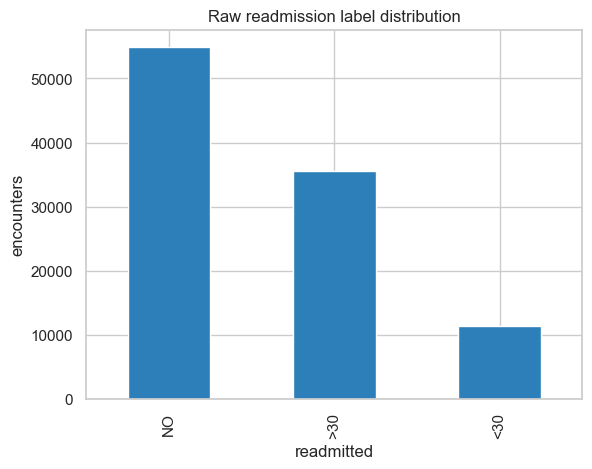

Positive class (<30) prevalence: 11.16%  -> imbalanced problem


In [2]:
ax = raw["readmitted"].value_counts().plot(kind="bar", color="#2c7fb8")
ax.set_title("Raw readmission label distribution"); ax.set_ylabel("encounters")
plt.show()

pos_rate = (raw["readmitted"] == "<30").mean()
print(f"Positive class (<30) prevalence: {pos_rate:.2%}  -> imbalanced problem")

## 2. Missingness

Which columns are missing, and *why*? Some 'missing' values are clinically meaningful (a lab simply wasn't ordered).

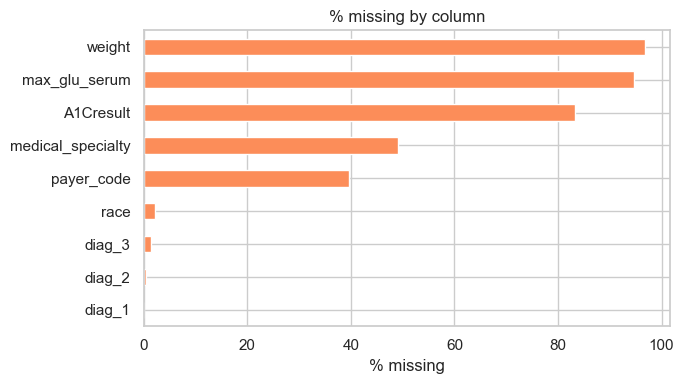

weight               96.86
max_glu_serum        94.75
A1Cresult            83.28
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02
dtype: float64

In [3]:
miss = raw.isnull().mean().mul(100).sort_values(ascending=False)
miss = miss[miss > 0]
ax = miss.plot(kind="barh", figsize=(7, 4), color="#fc8d59")
ax.set_title("% missing by column"); ax.set_xlabel("% missing")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
miss.round(2)

**Reading this:**
- `weight` (~97%) - too sparse to impute → drop.
- `max_glu_serum`, `A1Cresult` - high "missing", but here missing means the
  **test was not performed** → keep as an explicit category, do not drop.
- `medical_specialty`, `race` → impute an explicit `Unknown` level.

## 3. The leakage trap: repeat patients

Many patients appear more than once. Training and testing on the same patient inflates performance.

In [4]:
print("Total encounters:", len(raw))
print("Unique patients :", raw["patient_nbr"].nunique())
print("Repeat-encounter rows:", int(raw["patient_nbr"].duplicated().sum()))
print("\n-> We keep only the FIRST encounter per patient (Strack et al., 2014).")

Total encounters: 101766
Unique patients : 71518
Repeat-encounter rows: 30248

-> We keep only the FIRST encounter per patient (Strack et al., 2014).


## 4. What relates to readmission?

A few clinically intuitive signals.

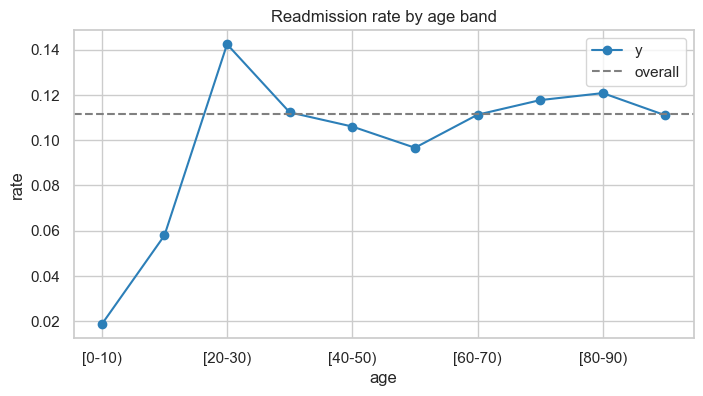

In [5]:
df = raw.copy()
df["y"] = (df["readmitted"] == "<30").astype(int)

age_order = ["[0-10)","[10-20)","[20-30)","[30-40)","[40-50)",
             "[50-60)","[60-70)","[70-80)","[80-90)","[90-100)"]
by_age = df.groupby("age")["y"].mean().reindex(age_order)
ax = by_age.plot(marker="o", figsize=(8,4), color="#2c7fb8")
ax.axhline(df["y"].mean(), ls="--", color="grey", label="overall")
ax.set_title("Readmission rate by age band"); ax.set_ylabel("rate"); ax.legend()
plt.show()

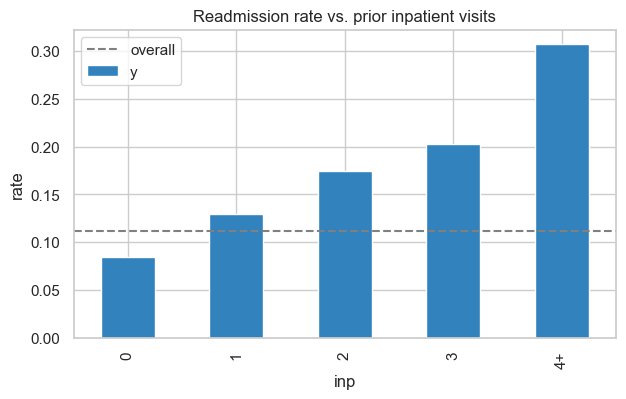

In [6]:
# Prior inpatient visits is one of the strongest signals.
tmp = df.copy()
tmp["inp"] = np.where(tmp["number_inpatient"] >= 4, "4+",
                      tmp["number_inpatient"].astype(int).astype(str))
order = ["0","1","2","3","4+"]
by_inp = tmp.groupby("inp")["y"].mean().reindex(order)
ax = by_inp.plot(kind="bar", figsize=(7,4), color="#3182bd")
ax.axhline(df["y"].mean(), ls="--", color="grey", label="overall")
ax.set_title("Readmission rate vs. prior inpatient visits")
ax.set_ylabel("rate"); ax.legend(); plt.show()

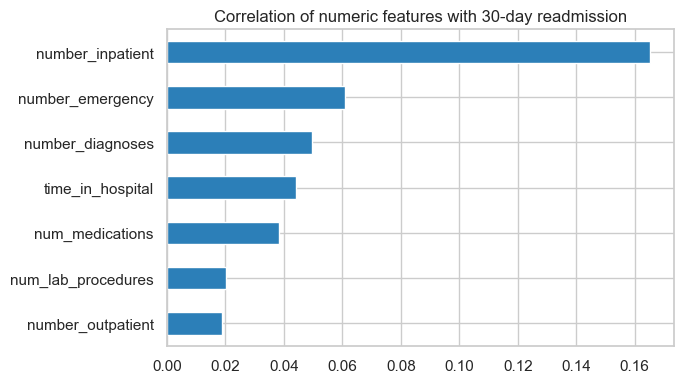

number_outpatient     0.018893
num_lab_procedures    0.020364
num_medications       0.038432
time_in_hospital      0.044199
number_diagnoses      0.049524
number_emergency      0.060747
number_inpatient      0.165147
Name: y, dtype: float64

In [7]:
# Numeric features: distribution and correlation with the target.
num = ["time_in_hospital","num_lab_procedures","num_medications",
       "number_inpatient","number_emergency","number_outpatient",
       "number_diagnoses"]
corr = df[num + ["y"]].corr()["y"].drop("y").sort_values()
ax = corr.plot(kind="barh", figsize=(7,4), color="#2c7fb8")
ax.set_title("Correlation of numeric features with 30-day readmission")
plt.tight_layout(); plt.show()
corr

## 5. Takeaways → modelling decisions

1. **Imbalanced** (~11% raw, ~9% after cleaning) → use class weights and
   evaluate with PR-AUC / recall, not accuracy.
2. **Leakage** → first encounter per patient; remove death/hospice discharges.
3. **Meaningful missingness** → keep `A1Cresult` / `max_glu_serum` as categories.
4. **High-cardinality diagnoses** → map ICD-9 to 9 clinical groups.
5. **Strongest signals** are prior utilisation (inpatient/emergency), length of
   stay, age and comorbidity count - later confirmed by SHAP.

These directly motivate `src/preprocessing.py` and `src/modeling.py`.